<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


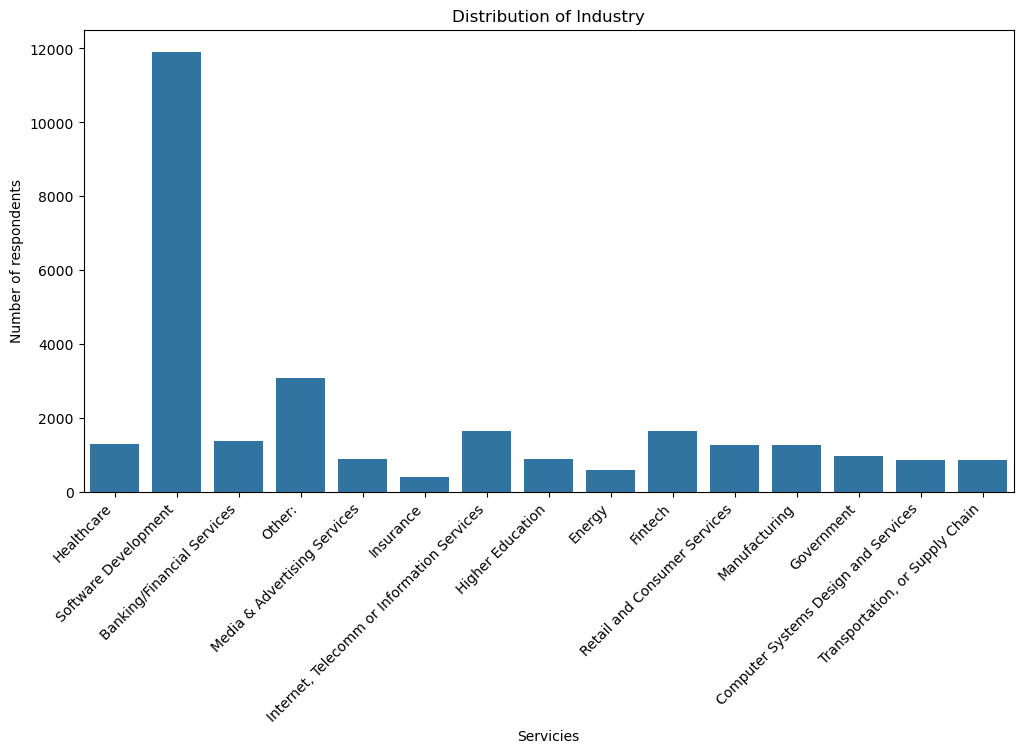

In [3]:
##Write your code here
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Industry')
plt.xlabel('Servicies')
plt.ylabel('Number of respondents')
plt.title('Distribution of Industry')
plt.xticks(rotation=45, ha='right')
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [18]:
##Write your code here
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
conv_mean= df['ConvertedCompYearly'].mean()
print('Mean:', conv_mean)

conv_median = df['ConvertedCompYearly'].median()
print('Median:', conv_median)

conv_std = df['ConvertedCompYearly'].std()
print('Standard Desviation:', conv_std)
print('='*50)
threshold = conv_mean + (3*conv_std)

outliers_comp = df[df['ConvertedCompYearly'] > threshold]

print(f'The average salary is: {conv_mean:.2f}')
print(f'The maximum normal limit (threshold) is: {threshold:.2f}')
print(f'Number of people exceeding the limit: {len(outliers_comp)}')
print('='*50)

outliers_comp[['ConvertedCompYearly', 'Industry']].sort_values(by = ['ConvertedCompYearly'], ascending=False
    ).rename(columns={'ConvertedCompYearly': 'Annual Salary (USD)'}).reset_index(names='Row Number').head(10).style.hide()




Mean: 86155.28726264134
Median: 65000.0
Standard Desviation: 186756.9730862951
The average salary is: 86155.29
The maximum normal limit (threshold) is: 646426.21
Number of people exceeding the limit: 89


Row Number,Annual Salary (USD),Industry
15837,16256603.000000,nan
12723,13818022.000000,Media & Advertising Services
28379,9000000.000000,Computer Systems Design and Services
17593,6340564.000000,Software Development
17672,4936778.000000,Software Development
19267,3367716.000000,Other:
23694,2584118.000000,nan
33720,2237846.000000,nan
34523,2153432.000000,Software Development
13763,2048046.000000,Media & Advertising Services


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Interquiartile Range: 75259.5
Lower bounds: -80177.25
Upper bounds: 220860.75
Outliers: 978


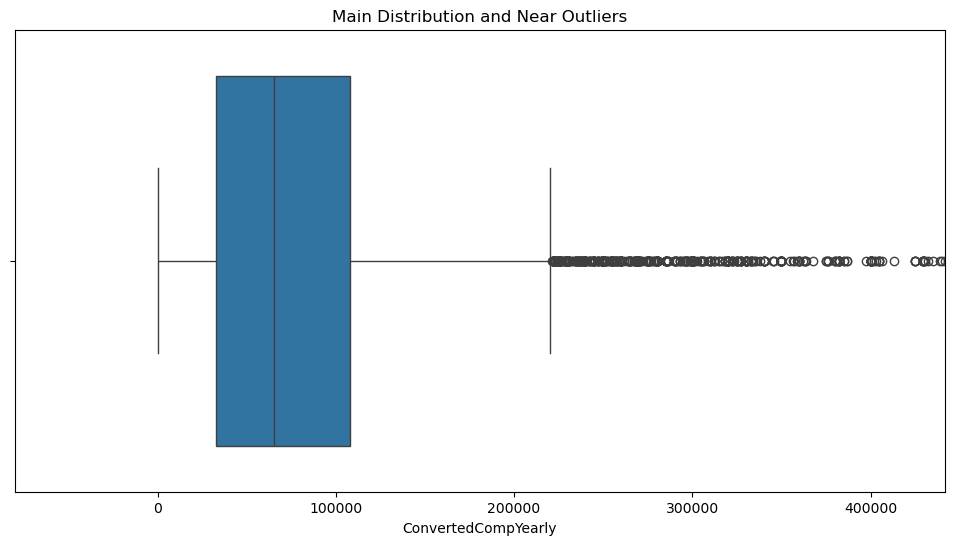

In [27]:
##Write your code here
q1 = df['ConvertedCompYearly'].quantile(0.25)
q3 = df['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
print('Interquiartile Range:', iqr)

lower = q1 - (1.5 *iqr)
upper = q3 + (1.5 *iqr)
print('Lower bounds:', lower)
print('Upper bounds:', upper)

outliers = df[(df['ConvertedCompYearly'] < lower) | (df['ConvertedCompYearly']>upper)]
print('Outliers:', outliers.shape[0])
print('=='*50)

plt.figure(figsize=(12,6))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.xlim(lower, upper *2)
plt.title('Main Distribution and Near Outliers')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [ ]:
##Write your code here
no_outliers = df[(df['ConvertedCompYearly'] > q1) | (df['ConvertedCompYearly']<q3)]
print('No outliers:', no_outliers.shape[0])


No outliers: 23435


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [38]:
##Write your code here
df['Age'].unique()
age_map = {
    '< 18 years old': 15,
    '18 - 24 years old': 21,
    '25 - 34 years old': 30,
    '35 - 44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['Age'] = df['Age'].map(age_map)

corr_matrix = df.corr(numeric_only=True)

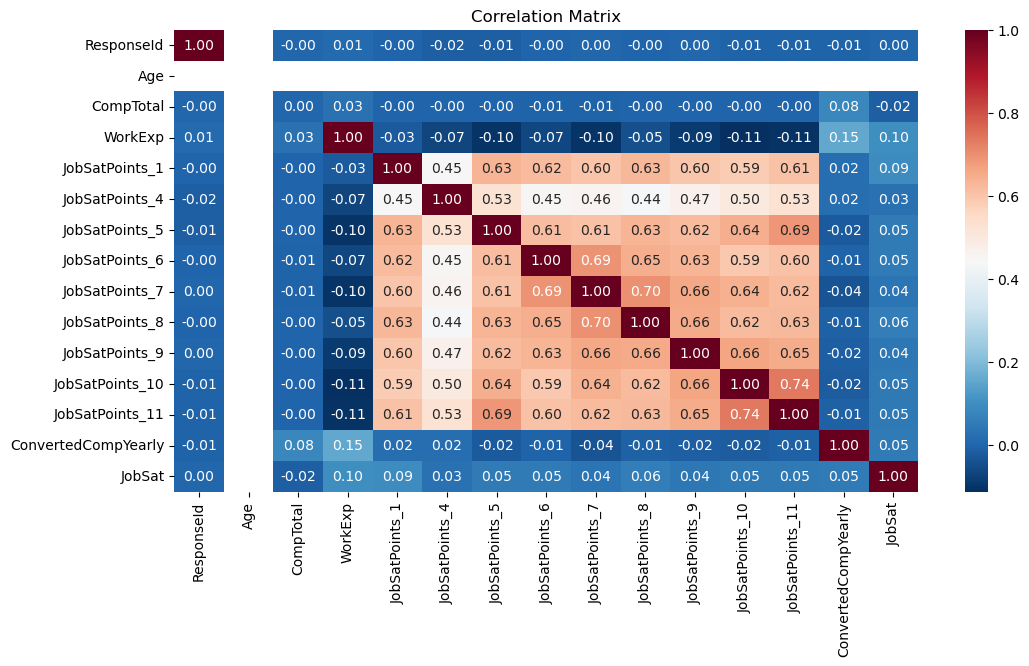

In [39]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot = True, fmt= '0.2f', cmap='RdBu_r')
plt.title('Correlation Matrix')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
